# QB weekly Silver facts

## tl;dr

This notebook creates `silver_qb_week` for the 2023–2025 contextual QB population at one row per `player_id + season + week + team`. The output contains **2,163 rows and 71 columns** across three season partitions.

All 63,783 canonical PBP dropbacks receive an exact player identifier: attempts and sacks use `passer_player_id`, while 3,378 scrambles use `rusher_player_id`. The contextual QB rows contain 63,662 dropbacks, 56,108 pass attempts, 4,184 sacks, and 6,077 meaningful rush attempts. Meaningful rushing separates 2,707 designed runs and 3,370 scrambles from 1,343 kneels.

Sacks and official QB rush attempts reconcile exactly with all 2,109 weekly-stat rows. Canonical PBP pass attempts are one lower because Aaron Rodgers has 33 weekly-stat attempts in 2025 Week 2 while PBP contains 32. The output preserves 54 snap-only QB rows with null weekly statistics and observed zero PBP opportunities. All declared identity, grain, relationship, denominator, null-versus-zero, range, and Parquet round-trip checks pass.


## Context & Methods

### Scope

The shared Silver notebooks established canonical player-week records, standardized plays, and team-week opportunity denominators. The WR and RB notebooks proved the position-specific pattern. This notebook completes the position-level Silver milestone with QB passing and rushing facts.

Weekly player statistics remain nullable source evidence. Standardized PBP supplies observed QB opportunities and classifications, including zeroes for QBs who appeared without a pass or rush. Team-week facts supply the denominators for transparent same-week shares.

### Key assumptions

- A contextual QB row has `QB` in weekly stat or snap-position evidence. Master and roster positions do not determine historical eligibility.
- Weekly stats remain authoritative for official passing, rushing, receiving, and turnover production. PBP counts remain separate and are reconciled before use as opportunity numerators.
- Pass attempts include spikes and exclude sacks. Passing dropbacks equal pass attempts plus sacks.
- Scrambles are both rush attempts and dropbacks. They identify the player through `rusher_player_id`, so complete QB dropbacks combine passer and rusher identity explicitly.
- Kneels remain visible as official rushing attempts but are excluded from meaningful QB rushing.
- Designed QB rushes exclude kneels and scrambles. Meaningful QB rushes equal designed runs plus scrambles.
- A zero team denominator produces a null share. A valid denominator with no player opportunity produces a zero share.
- Every calculation is same-week. Efficiency rates, fantasy points, rolling features, rankings, and future-looking features remain outside this Silver dataset.


## Data

### 1. Set up paths, grains, and selected fields


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


SEASONS = [2023, 2024, 2025]
QB_WEEK_GRAIN = ["player_id", "season", "week", "team"]
PLAYER_GAME_TEAM_KEY = ["player_id", "game_id", "team"]
TEAM_WEEK_GRAIN = ["team", "season", "week"]

# Find the repository root whether this runs from Jupyter or nbconvert.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ROADMAP.md").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "ROADMAP.md").exists():
            PROJECT_ROOT = parent
            break
    else:
        raise RuntimeError("Could not locate the repository root.")

SILVER_DIR = PROJECT_ROOT / "data/silver"
PLAYER_WEEK_DIR = SILVER_DIR / "player_week"
STANDARDIZED_PLAYS_DIR = SILVER_DIR / "standardized_plays"
TEAM_WEEK_OPPORTUNITY_DIR = SILVER_DIR / "team_week_opportunity"
QB_WEEK_DIR = SILVER_DIR / "qb_week"

PLAYER_WEEK_COLUMNS = [
    "player_id",
    "game_id",
    "season",
    "week",
    "game_type",
    "season_type",
    "team",
    "opponent_team",
    "display_name",
    "stats_position",
    "snap_position",
    "has_stat_record",
    "has_snap_record",
    "participated_game",
    "offensive_participant",
    "offense_snaps",
    "offense_snap_pct",
    "passing_completions",
    "passing_attempts",
    "passing_yards",
    "passing_touchdowns",
    "passing_interceptions",
    "sacks_suffered",
    "passing_first_downs",
    "passing_2pt_conversions",
    "rushing_attempts",
    "rushing_yards",
    "rushing_touchdowns",
    "rushing_first_downs",
    "rushing_2pt_conversions",
    "receiving_targets",
    "receptions",
    "receiving_yards",
    "receiving_touchdowns",
    "receiving_air_yards",
    "receiving_yards_after_catch",
    "receiving_first_downs",
    "receiving_2pt_conversions",
    "fumbles",
    "fumbles_lost",
    "special_teams_touchdowns",
]

PBP_COLUMNS = [
    "game_id",
    "play_id",
    "team",
    "passer_player_id",
    "rusher_player_id",
    "is_pass_attempt",
    "is_dropback",
    "is_sack",
    "is_qb_spike",
    "is_qb_kneel",
    "is_qb_scramble",
    "is_rush_attempt",
    "is_non_kneel_rush_attempt",
    "is_designed_rush_attempt",
    "is_red_zone_rush_attempt",
    "is_goal_line_rush_attempt",
]

TEAM_WEEK_COLUMNS = [
    "team",
    "season",
    "week",
    "game_id",
    "team_dropbacks",
    "team_pass_attempts",
    "team_sacks",
    "team_rush_attempts",
    "team_non_kneel_rush_attempts",
    "team_designed_rush_attempts",
    "team_qb_kneels",
    "team_qb_spikes",
    "team_qb_scrambles",
    "team_red_zone_rush_attempts",
    "team_goal_line_rush_attempts",
]

pd.set_option("display.max_columns", 80)


### 2. Define the QB metric contract

The contract keeps official statistics, passing-play opportunity, and meaningful rushing opportunity separate. That prevents sacks, spikes, kneels, scrambles, and designed runs from being treated as interchangeable events.


In [2]:
metric_contract = pd.DataFrame(
    [
        ["pbp_pass_attempts", "Canonical pass attempts, including spikes and excluding sacks", "standardized plays"],
        ["pbp_sacks", "Canonical sacks charged to the passer", "standardized plays"],
        ["qb_spikes", "Canonical QB spikes included in pass attempts", "standardized plays"],
        ["passing_dropbacks", "pbp_pass_attempts + pbp_sacks", "player passing-play components"],
        ["qb_dropbacks", "passing_dropbacks + qb_scrambles", "passing and rushing identifiers"],
        ["pbp_rush_attempts", "Canonical official QB rush attempts, including kneels", "standardized plays"],
        ["qb_kneels", "Canonical QB kneel-down attempts", "standardized plays"],
        ["qb_scrambles", "Canonical QB scrambles", "standardized plays"],
        ["designed_qb_rush_attempts", "Non-kneel QB rushes excluding scrambles", "standardized plays"],
        ["meaningful_qb_rush_attempts", "designed_qb_rush_attempts + qb_scrambles", "player rushing components"],
        ["dropback_share", "qb_dropbacks / team_dropbacks", "same-week team denominator"],
        ["meaningful_qb_rush_share", "meaningful_qb_rush_attempts / team_non_kneel_rush_attempts", "same-week team denominator"],
    ],
    columns=["field", "definition", "source_or_denominator"],
)

metric_contract


,field,definition,source_or_denominator
0,pbp_pass_attempts,"Canonical pass attempts, including spikes and ...",standardized plays
1,pbp_sacks,Canonical sacks charged to the passer,standardized plays
2,qb_spikes,Canonical QB spikes included in pass attempts,standardized plays
3,passing_dropbacks,pbp_pass_attempts + pbp_sacks,player passing-play components
4,qb_dropbacks,passing_dropbacks + qb_scrambles,passing and rushing identifiers
5,pbp_rush_attempts,"Canonical official QB rush attempts, including...",standardized plays
6,qb_kneels,Canonical QB kneel-down attempts,standardized plays
7,qb_scrambles,Canonical QB scrambles,standardized plays
8,designed_qb_rush_attempts,Non-kneel QB rushes excluding scrambles,standardized plays
9,meaningful_qb_rush_attempts,designed_qb_rush_attempts + qb_scrambles,player rushing components


### 3. Load the persisted inputs


In [3]:
player_week_paths = sorted(PLAYER_WEEK_DIR.glob("*.parquet"))
standardized_play_paths = sorted(STANDARDIZED_PLAYS_DIR.glob("*.parquet"))
team_week_paths = sorted(TEAM_WEEK_OPPORTUNITY_DIR.glob("*.parquet"))

assert len(player_week_paths) == len(SEASONS)
assert len(standardized_play_paths) == len(SEASONS)
assert len(team_week_paths) == len(SEASONS)

player_week = pd.concat(
    [pd.read_parquet(path) for path in player_week_paths],
    ignore_index=True,
)
standardized_plays = pd.concat(
    [pd.read_parquet(path, columns=PBP_COLUMNS) for path in standardized_play_paths],
    ignore_index=True,
)
team_week_opportunity = pd.concat(
    [pd.read_parquet(path, columns=TEAM_WEEK_COLUMNS) for path in team_week_paths],
    ignore_index=True,
)

input_summary = pd.DataFrame(
    [
        ["Silver player_week", len(player_week), len(player_week.columns), len(PLAYER_WEEK_COLUMNS)],
        ["Silver standardized_plays", len(standardized_plays), 56, len(standardized_plays.columns)],
        ["Silver team_week_opportunity", len(team_week_opportunity), 24, len(team_week_opportunity.columns)],
    ],
    columns=["input", "rows", "columns_available", "columns_loaded_or_selected"],
)

input_summary


,input,rows,columns_available,columns_loaded_or_selected
0,Silver player_week,79708,54,41
1,Silver standardized_plays,147928,56,16
2,Silver team_week_opportunity,1710,24,15


## Results

### 4. Validate input grains and relationships


In [4]:
assert set(player_week["season"].unique()) == set(SEASONS)
assert set(team_week_opportunity["season"].unique()) == set(SEASONS)

assert player_week[QB_WEEK_GRAIN].notna().all().all()
assert not player_week.duplicated(QB_WEEK_GRAIN).any()
assert team_week_opportunity[TEAM_WEEK_GRAIN].notna().all().all()
assert not team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).any()

input_grain_summary = pd.DataFrame(
    [
        ["player_week", " + ".join(QB_WEEK_GRAIN), len(player_week), player_week.duplicated(QB_WEEK_GRAIN).sum()],
        ["team_week_opportunity", " + ".join(TEAM_WEEK_GRAIN), len(team_week_opportunity), team_week_opportunity.duplicated(TEAM_WEEK_GRAIN).sum()],
    ],
    columns=["input", "declared_grain", "rows", "duplicate_grain_rows"],
)

input_grain_summary


,input,declared_grain,rows,duplicate_grain_rows
0,player_week,player_id + season + week + team,79708,0
1,team_week_opportunity,team + season + week,1710,0


### 5. Establish the contextual QB population

A weekly stat or snap position of `QB` establishes the contextual population. This preserves stat-and-snap, snap-only, and stats-only observations without using the player's latest master or roster position as a historical override.


In [5]:
is_qb_week = player_week["stats_position"].eq("QB") | player_week["snap_position"].eq("QB")

qb_base = (
    player_week.loc[is_qb_week, PLAYER_WEEK_COLUMNS]
    .sort_values(["season", "week", "team", "player_id"])
    .reset_index(drop=True)
)

assert qb_base[QB_WEEK_GRAIN].notna().all().all()
assert not qb_base.duplicated(QB_WEEK_GRAIN).any()

qb_population_summary = (
    qb_base.groupby(["season", "has_stat_record", "has_snap_record"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
)

qb_position_evidence = (
    qb_base.groupby(["stats_position", "snap_position"], dropna=False)
    .size()
    .rename("rows")
    .reset_index()
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)

print(f"Contextual QB player-weeks: {len(qb_base):,}")
display(qb_population_summary)
qb_position_evidence


Contextual QB player-weeks: 2,163


,season,has_stat_record,has_snap_record,rows
0,2023,False,True,22
1,2023,True,True,707
2,2024,False,True,21
3,2024,True,True,697
4,2025,False,True,11
5,2025,True,False,1
6,2025,True,True,704


,stats_position,snap_position,rows
0,QB,QB,2078
1,NaN,QB,54
2,TE,QB,29
3,QB,NaN,1
4,WR,QB,1


### 6. Assign every dropback to the correct player identifier

Pass attempts and sacks identify the QB through `passer_player_id`. Scrambles have no passer identifier and instead use `rusher_player_id`. Combining those mutually exclusive paths maps every canonical dropback without using names.


In [6]:
pass_or_sack = standardized_plays["is_pass_attempt"] | standardized_plays["is_sack"]

standardized_plays["dropback_player_id"] = (
    standardized_plays["passer_player_id"]
    .where(pass_or_sack)
    .combine_first(
        standardized_plays["rusher_player_id"].where(
            standardized_plays["is_qb_scramble"]
        )
    )
)

dropback_identity_summary = pd.DataFrame(
    {
        "check": [
            "canonical dropbacks",
            "dropbacks with mapped player_id",
            "mapped player IDs outside canonical dropbacks",
            "scrambles with passer_player_id",
        ],
        "rows": [
            int(standardized_plays["is_dropback"].sum()),
            int((standardized_plays["is_dropback"] & standardized_plays["dropback_player_id"].notna()).sum()),
            int((~standardized_plays["is_dropback"] & standardized_plays["dropback_player_id"].notna()).sum()),
            int((standardized_plays["is_qb_scramble"] & standardized_plays["passer_player_id"].notna()).sum()),
        ],
    }
)

assert standardized_plays.loc[
    standardized_plays["is_dropback"], "dropback_player_id"
].notna().all()
assert standardized_plays.loc[
    standardized_plays["dropback_player_id"].notna(), "is_dropback"
].all()

dropback_identity_summary


,check,rows
0,canonical dropbacks,63783
1,dropbacks with mapped player_id,63783
2,mapped player IDs outside canonical dropbacks,0
3,scrambles with passer_player_id,0


### 7. Aggregate QB passing and rushing opportunity

Passing, rushing, and complete dropback observations are aggregated separately at player-game-team grain. Keeping the paths visible makes the player identifier and each classification auditable.


In [7]:
passer_opportunity = (
    standardized_plays.loc[standardized_plays["passer_player_id"].notna()]
    .groupby(["passer_player_id", "game_id", "team"], dropna=False)
    .agg(
        pbp_pass_attempts=("is_pass_attempt", "sum"),
        pbp_sacks=("is_sack", "sum"),
        qb_spikes=("is_qb_spike", "sum"),
    )
    .reset_index()
    .rename(columns={"passer_player_id": "player_id"})
)

rusher_opportunity = (
    standardized_plays.loc[standardized_plays["rusher_player_id"].notna()]
    .groupby(["rusher_player_id", "game_id", "team"], dropna=False)
    .agg(
        pbp_rush_attempts=("is_rush_attempt", "sum"),
        source_non_kneel_rush_attempts=("is_non_kneel_rush_attempt", "sum"),
        qb_kneels=("is_qb_kneel", "sum"),
        qb_scrambles=("is_qb_scramble", "sum"),
        designed_qb_rush_attempts=("is_designed_rush_attempt", "sum"),
        red_zone_qb_rush_attempts=("is_red_zone_rush_attempt", "sum"),
        goal_line_qb_rush_attempts=("is_goal_line_rush_attempt", "sum"),
    )
    .reset_index()
    .rename(columns={"rusher_player_id": "player_id"})
)

dropback_opportunity = (
    standardized_plays.loc[standardized_plays["dropback_player_id"].notna()]
    .groupby(["dropback_player_id", "game_id", "team"], dropna=False)
    .agg(qb_dropbacks=("is_dropback", "sum"))
    .reset_index()
    .rename(columns={"dropback_player_id": "player_id"})
)

assert not passer_opportunity.duplicated(PLAYER_GAME_TEAM_KEY).any()
assert not rusher_opportunity.duplicated(PLAYER_GAME_TEAM_KEY).any()
assert not dropback_opportunity.duplicated(PLAYER_GAME_TEAM_KEY).any()

pd.DataFrame(
    [
        ["passer opportunity", len(passer_opportunity), len(passer_opportunity.columns)],
        ["rusher opportunity", len(rusher_opportunity), len(rusher_opportunity.columns)],
        ["complete dropback opportunity", len(dropback_opportunity), len(dropback_opportunity.columns)],
    ],
    columns=["intermediate", "rows", "columns"],
)


,intermediate,rows,columns
0,passer opportunity,2117,6
1,rusher opportunity,7102,10
2,complete dropback opportunity,2124,4


In [8]:
qb_with_opportunity = (
    qb_base.merge(
        passer_opportunity,
        on=PLAYER_GAME_TEAM_KEY,
        how="left",
        validate="one_to_one",
    )
    .merge(
        rusher_opportunity,
        on=PLAYER_GAME_TEAM_KEY,
        how="left",
        validate="one_to_one",
    )
    .merge(
        dropback_opportunity,
        on=PLAYER_GAME_TEAM_KEY,
        how="left",
        validate="one_to_one",
    )
)

AGGREGATED_PBP_COUNT_COLUMNS = [
    "pbp_pass_attempts",
    "pbp_sacks",
    "qb_spikes",
    "pbp_rush_attempts",
    "source_non_kneel_rush_attempts",
    "qb_kneels",
    "qb_scrambles",
    "designed_qb_rush_attempts",
    "red_zone_qb_rush_attempts",
    "goal_line_qb_rush_attempts",
    "qb_dropbacks",
]

# Complete game-level PBP makes a missing player aggregate an observed zero opportunity.
for column in AGGREGATED_PBP_COUNT_COLUMNS:
    qb_with_opportunity[column] = (
        qb_with_opportunity[column].fillna(0).astype("Int64")
    )

qb_with_opportunity["passing_dropbacks"] = (
    qb_with_opportunity["pbp_pass_attempts"] + qb_with_opportunity["pbp_sacks"]
).astype("Int64")
qb_with_opportunity["meaningful_qb_rush_attempts"] = (
    qb_with_opportunity["designed_qb_rush_attempts"]
    + qb_with_opportunity["qb_scrambles"]
).astype("Int64")

assert len(qb_with_opportunity) == len(qb_base)
qb_with_opportunity[
    AGGREGATED_PBP_COUNT_COLUMNS
    + ["passing_dropbacks", "meaningful_qb_rush_attempts"]
].sum()


pbp_pass_attempts                 56108
pbp_sacks                          4184
qb_spikes                           224
pbp_rush_attempts                  7420
source_non_kneel_rush_attempts     6077
qb_kneels                          1343
qb_scrambles                       3370
designed_qb_rush_attempts          2707
red_zone_qb_rush_attempts          1271
goal_line_qb_rush_attempts          395
qb_dropbacks                      63662
passing_dropbacks                 60292
meaningful_qb_rush_attempts        6077
dtype: Int64

### 8. Validate the QB opportunity relationships

These identities are the core reason for a QB-specific table. They prove that kneels are removable from meaningful rushing and that scramble dropbacks are retained exactly once.


In [9]:
assert qb_with_opportunity["passing_dropbacks"].eq(
    qb_with_opportunity["pbp_pass_attempts"] + qb_with_opportunity["pbp_sacks"]
).all()
assert qb_with_opportunity["qb_dropbacks"].eq(
    qb_with_opportunity["passing_dropbacks"] + qb_with_opportunity["qb_scrambles"]
).all()
assert qb_with_opportunity["pbp_rush_attempts"].eq(
    qb_with_opportunity["source_non_kneel_rush_attempts"] + qb_with_opportunity["qb_kneels"]
).all()
assert qb_with_opportunity["meaningful_qb_rush_attempts"].eq(
    qb_with_opportunity["source_non_kneel_rush_attempts"]
).all()
assert qb_with_opportunity["qb_spikes"].le(
    qb_with_opportunity["pbp_pass_attempts"]
).all()

relationship_summary = pd.DataFrame(
    [
        ["passing dropbacks", qb_with_opportunity["passing_dropbacks"].sum(), "pass attempts + sacks"],
        ["complete QB dropbacks", qb_with_opportunity["qb_dropbacks"].sum(), "passing dropbacks + scrambles"],
        ["official QB rush attempts", qb_with_opportunity["pbp_rush_attempts"].sum(), "non-kneel rushes + kneels"],
        ["meaningful QB rush attempts", qb_with_opportunity["meaningful_qb_rush_attempts"].sum(), "designed runs + scrambles"],
    ],
    columns=["metric", "total", "validated_identity"],
)

relationship_summary


,metric,total,validated_identity
0,passing dropbacks,60292,pass attempts + sacks
1,complete QB dropbacks,63662,passing dropbacks + scrambles
2,official QB rush attempts,7420,non-kneel rushes + kneels
3,meaningful QB rush attempts,6077,designed runs + scrambles


### 9. Reconcile PBP opportunity with weekly-stat evidence

Sacks and official rush attempts should match exactly. The shared play-classification notebook already documented one bounded passing disagreement: Aaron Rodgers has 33 weekly-stat attempts in 2025 Week 2 while canonical PBP contains 32.


In [10]:
stat_qb_rows = qb_with_opportunity["has_stat_record"]

reconciliation_definitions = {
    "pass attempts": ("passing_attempts", "pbp_pass_attempts"),
    "sacks": ("sacks_suffered", "pbp_sacks"),
    "rush attempts": ("rushing_attempts", "pbp_rush_attempts"),
}

opportunity_reconciliation_records = []
for metric, (stat_column, pbp_column) in reconciliation_definitions.items():
    stat_values = qb_with_opportunity.loc[stat_qb_rows, stat_column].astype("float64")
    pbp_values = qb_with_opportunity.loc[stat_qb_rows, pbp_column].astype("float64")
    opportunity_reconciliation_records.append(
        [
            metric,
            stat_values.sum(),
            pbp_values.sum(),
            pbp_values.sub(stat_values).sum(),
            pbp_values.ne(stat_values).sum(),
        ]
    )

opportunity_reconciliation = pd.DataFrame(
    opportunity_reconciliation_records,
    columns=[
        "metric",
        "weekly_stat_total",
        "pbp_total",
        "total_difference",
        "player_week_differences",
    ],
)

expected_differences = {
    "pass attempts": (-1, 1),
    "sacks": (0, 0),
    "rush attempts": (0, 0),
}
observed_differences = {
    row.metric: (row.total_difference, row.player_week_differences)
    for row in opportunity_reconciliation.itertuples(index=False)
}
assert observed_differences == expected_differences

opportunity_reconciliation


,metric,weekly_stat_total,pbp_total,total_difference,player_week_differences
0,pass attempts,56109.0,56108.0,-1.0,1
1,sacks,4184.0,4184.0,0.0,0
2,rush attempts,7420.0,7420.0,0.0,0


In [11]:
pass_reconciliation_exceptions = qb_with_opportunity.loc[
    stat_qb_rows
    & qb_with_opportunity["passing_attempts"].astype("float64").ne(
        qb_with_opportunity["pbp_pass_attempts"].astype("float64")
    ),
    [
        "player_id",
        "display_name",
        "season",
        "week",
        "game_id",
        "team",
        "passing_attempts",
        "pbp_pass_attempts",
    ],
].copy()

assert set(
    pass_reconciliation_exceptions[["player_id", "game_id"]].itertuples(index=False, name=None)
) == {("00-0023459", "2025_02_SEA_PIT")}

pass_reconciliation_exceptions


,player_id,display_name,season,week,game_id,team,passing_attempts,pbp_pass_attempts
1516,00-0023459,Aaron Rodgers,2025,2,2025_02_SEA_PIT,PIT,33,32


### 10. Add team-week opportunity denominators

Every QB observation must match one team-week row. The retained game identifiers are checked before the duplicate team-side key is removed.


In [12]:
qb_with_team = qb_with_opportunity.merge(
    team_week_opportunity,
    on=TEAM_WEEK_GRAIN,
    how="left",
    validate="many_to_one",
    suffixes=("", "_team"),
    indicator="team_week_join",
)

assert len(qb_with_team) == len(qb_with_opportunity)
assert qb_with_team["team_week_join"].eq("both").all()
assert qb_with_team["game_id"].eq(qb_with_team["game_id_team"]).all()

qb_with_team = qb_with_team.drop(columns=["game_id_team", "team_week_join"])

pd.DataFrame(
    {
        "check": ["QB observations", "team-week matches", "game_id disagreements"],
        "rows": [len(qb_with_team), len(qb_with_team), 0],
    }
)


,check,rows
0,QB observations,2163
1,team-week matches,2163
2,game_id disagreements,0


### 11. Calculate transparent QB opportunity shares

Passing shares describe control of the team's passing role. Rushing shares describe meaningful, designed, scramble, red-zone, and goal-line opportunity without counting kneel-downs as fantasy-relevant usage.


In [13]:
SHARE_DEFINITIONS = {
    "dropback_share": ("qb_dropbacks", "team_dropbacks"),
    "pass_attempt_share": ("pbp_pass_attempts", "team_pass_attempts"),
    "meaningful_qb_rush_share": ("meaningful_qb_rush_attempts", "team_non_kneel_rush_attempts"),
    "designed_qb_rush_share": ("designed_qb_rush_attempts", "team_designed_rush_attempts"),
    "qb_scramble_share": ("qb_scrambles", "team_qb_scrambles"),
    "red_zone_qb_rush_share": ("red_zone_qb_rush_attempts", "team_red_zone_rush_attempts"),
    "goal_line_qb_rush_share": ("goal_line_qb_rush_attempts", "team_goal_line_rush_attempts"),
}

for share_column, (numerator_column, denominator_column) in SHARE_DEFINITIONS.items():
    valid_denominator = qb_with_team[denominator_column].ne(0)
    qb_with_team[share_column] = (
        qb_with_team[numerator_column]
        .div(qb_with_team[denominator_column].where(valid_denominator))
        .astype("Float64")
    )
    assert qb_with_team.loc[~valid_denominator, share_column].isna().all()
    assert qb_with_team[share_column].dropna().between(0, 1, inclusive="both").all()

share_behavior_summary = pd.DataFrame(
    [
        {
            "share": share_column,
            "non_null_rows": qb_with_team[share_column].notna().sum(),
            "zero_denominator_rows": qb_with_team[denominator_column].eq(0).sum(),
            "minimum": qb_with_team[share_column].min(),
            "maximum": qb_with_team[share_column].max(),
        }
        for share_column, (_, denominator_column) in SHARE_DEFINITIONS.items()
    ]
)

share_behavior_summary


,share,non_null_rows,zero_denominator_rows,minimum,maximum
0,dropback_share,2163,0,0.0,1.000000
1,pass_attempt_share,2163,0,0.0,1.000000
2,meaningful_qb_rush_share,2163,0,0.0,0.588235
3,designed_qb_rush_share,2163,0,0.0,0.521739
4,qb_scramble_share,1690,473,0.0,1.000000
5,red_zone_qb_rush_share,2001,162,0.0,1.000000
6,goal_line_qb_rush_share,1375,788,0.0,1.000000


### 12. Create `silver_qb_week`


In [14]:
PBP_OPPORTUNITY_COLUMNS = [
    "pbp_pass_attempts",
    "pbp_sacks",
    "qb_spikes",
    "passing_dropbacks",
    "qb_dropbacks",
    "pbp_rush_attempts",
    "qb_kneels",
    "qb_scrambles",
    "designed_qb_rush_attempts",
    "meaningful_qb_rush_attempts",
    "red_zone_qb_rush_attempts",
    "goal_line_qb_rush_attempts",
]

TEAM_DENOMINATOR_COLUMNS = [
    column
    for column in TEAM_WEEK_COLUMNS
    if column not in ["team", "season", "week", "game_id"]
]

QB_WEEK_COLUMNS = [
    *PLAYER_WEEK_COLUMNS,
    *PBP_OPPORTUNITY_COLUMNS,
    *TEAM_DENOMINATOR_COLUMNS,
    *SHARE_DEFINITIONS.keys(),
]

silver_qb_week = (
    qb_with_team[QB_WEEK_COLUMNS]
    .sort_values(["season", "week", "team", "player_id"])
    .reset_index(drop=True)
)

assert len(silver_qb_week.columns) == len(set(silver_qb_week.columns))
assert silver_qb_week[QB_WEEK_GRAIN].notna().all().all()
assert not silver_qb_week.duplicated(QB_WEEK_GRAIN).any()
assert silver_qb_week.groupby(QB_WEEK_GRAIN)["game_id"].nunique().le(1).all()

pd.DataFrame(
    {
        "dataset": ["silver_qb_week"],
        "rows": [len(silver_qb_week)],
        "columns": [len(silver_qb_week.columns)],
        "grain": [" + ".join(QB_WEEK_GRAIN)],
        "duplicate_grain_rows": [silver_qb_week.duplicated(QB_WEEK_GRAIN).sum()],
        "null_grain_rows": [silver_qb_week[QB_WEEK_GRAIN].isna().any(axis=1).sum()],
    }
)


,dataset,rows,columns,grain,duplicate_grain_rows,null_grain_rows
0,silver_qb_week,2163,71,player_id + season + week + team,0,0


### 13. Validate missing statistics versus observed zero opportunity


In [15]:
snap_only_qb = silver_qb_week.loc[
    ~silver_qb_week["has_stat_record"] & silver_qb_week["has_snap_record"]
]
stats_only_qb = silver_qb_week.loc[
    silver_qb_week["has_stat_record"] & ~silver_qb_week["has_snap_record"]
]

assert snap_only_qb["passing_attempts"].isna().all()
assert snap_only_qb["rushing_attempts"].isna().all()
assert snap_only_qb["qb_dropbacks"].eq(0).all()
assert snap_only_qb["pbp_rush_attempts"].eq(0).all()
assert snap_only_qb.loc[snap_only_qb["team_dropbacks"].ne(0), "dropback_share"].eq(0).all()
assert snap_only_qb.loc[
    snap_only_qb["team_non_kneel_rush_attempts"].ne(0), "meaningful_qb_rush_share"
].eq(0).all()
assert stats_only_qb["participated_game"].isna().all()

null_zero_summary = pd.DataFrame(
    [
        [
            "snap-only QB rows",
            len(snap_only_qb),
            snap_only_qb["passing_attempts"].isna().sum(),
            snap_only_qb["qb_dropbacks"].eq(0).sum(),
            snap_only_qb["meaningful_qb_rush_attempts"].eq(0).sum(),
        ],
        [
            "stats-only QB rows",
            len(stats_only_qb),
            stats_only_qb["passing_attempts"].isna().sum(),
            stats_only_qb["qb_dropbacks"].eq(0).sum(),
            stats_only_qb["meaningful_qb_rush_attempts"].eq(0).sum(),
        ],
    ],
    columns=[
        "population",
        "rows",
        "null_weekly_pass_attempts",
        "zero_pbp_dropbacks",
        "zero_meaningful_rushes",
    ],
)

null_zero_summary


,population,rows,null_weekly_pass_attempts,zero_pbp_dropbacks,zero_meaningful_rushes
0,snap-only QB rows,54,54,54,54
1,stats-only QB rows,1,0,1,1


### 14. Confirm QB opportunities remain within team opportunity


In [16]:
COUNT_RECONCILIATIONS = {
    "dropbacks": ("qb_dropbacks", "team_dropbacks"),
    "pass_attempts": ("pbp_pass_attempts", "team_pass_attempts"),
    "sacks": ("pbp_sacks", "team_sacks"),
    "rush_attempts": ("pbp_rush_attempts", "team_rush_attempts"),
    "kneels": ("qb_kneels", "team_qb_kneels"),
    "scrambles": ("qb_scrambles", "team_qb_scrambles"),
    "designed_rush_attempts": ("designed_qb_rush_attempts", "team_designed_rush_attempts"),
    "red_zone_rush_attempts": ("red_zone_qb_rush_attempts", "team_red_zone_rush_attempts"),
    "goal_line_rush_attempts": ("goal_line_qb_rush_attempts", "team_goal_line_rush_attempts"),
}

team_qb_reconciliation_records = []
for metric, (qb_column, team_column) in COUNT_RECONCILIATIONS.items():
    grouped = (
        silver_qb_week.groupby(TEAM_WEEK_GRAIN, dropna=False)
        .agg(qb_total=(qb_column, "sum"), team_total=(team_column, "first"))
        .reset_index()
    )
    exceptions = grouped["qb_total"].gt(grouped["team_total"])
    team_qb_reconciliation_records.append(
        [metric, grouped["qb_total"].sum(), grouped["team_total"].sum(), exceptions.sum()]
    )

team_qb_reconciliation = pd.DataFrame(
    team_qb_reconciliation_records,
    columns=["metric", "QB_total", "team_total", "team_weeks_QB_exceeds_team"],
)

assert team_qb_reconciliation["team_weeks_QB_exceeds_team"].eq(0).all()
team_qb_reconciliation


,metric,QB_total,team_total,team_weeks_QB_exceeds_team
0,dropbacks,63662,63783,0
1,pass_attempts,56108,56202,0
2,sacks,4184,4203,0
3,rush_attempts,7420,46041,0
4,kneels,1343,1343,0
5,scrambles,3370,3378,0
6,designed_rush_attempts,2707,41320,0
7,red_zone_rush_attempts,1271,7935,0
8,goal_line_rush_attempts,395,2340,0


### 15. Check recognizable QB volume and team changes


In [17]:
regular_season_leaders = (
    silver_qb_week.loc[silver_qb_week["season_type"].eq("REG")]
    .groupby(["season", "player_id", "display_name"], dropna=False)
    .agg(
        games=("game_id", "nunique"),
        pass_attempts=("pbp_pass_attempts", "sum"),
        passing_yards=("passing_yards", "sum"),
        passing_touchdowns=("passing_touchdowns", "sum"),
        interceptions=("passing_interceptions", "sum"),
        meaningful_rushes=("meaningful_qb_rush_attempts", "sum"),
        designed_rushes=("designed_qb_rush_attempts", "sum"),
        scrambles=("qb_scrambles", "sum"),
        rushing_yards=("rushing_yards", "sum"),
    )
    .reset_index()
    .sort_values(["season", "pass_attempts"], ascending=[True, False])
    .groupby("season", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

regular_season_leaders


,season,player_id,display_name,games,pass_attempts,passing_yards,passing_touchdowns,interceptions,meaningful_rushes,designed_rushes,scrambles,rushing_yards
0,2023,00-0037077,Sam Howell,17,612,3946,21,21,44,12,32,263
1,2023,00-0033106,Jared Goff,17,605,4575,30,12,13,6,7,21
2,2023,00-0033873,Patrick Mahomes,16,597,4183,27,14,54,4,50,389
3,2023,00-0033077,Dak Prescott,17,590,4516,36,9,43,16,27,242
4,2023,00-0034857,Josh Allen,17,579,4306,29,18,102,54,48,524
5,2024,00-0036442,Joe Burrow,17,652,4918,43,9,31,9,22,201
6,2024,00-0023459,Aaron Rodgers,17,584,3897,28,11,17,1,16,107
7,2024,00-0033873,Patrick Mahomes,16,581,3928,26,11,38,1,37,307
8,2024,00-0030565,Geno Smith,17,578,4320,21,15,40,16,24,272
9,2024,00-0034855,Baker Mayfield,17,570,4500,41,16,53,11,42,378


In [18]:
qb_team_changes = (
    silver_qb_week.groupby(["player_id", "display_name", "season"], dropna=False)
    .agg(
        teams=("team", "nunique"),
        team_list=("team", lambda values: ", ".join(sorted(set(values)))),
    )
    .reset_index()
    .query("teams > 1")
    .sort_values(["season", "display_name"])
    .reset_index(drop=True)
)

same_week_multi_team = (
    silver_qb_week.groupby(["player_id", "season", "week"], dropna=False)["team"]
    .nunique()
    .gt(1)
    .sum()
)

assert same_week_multi_team == 0
print(f"QB player-seasons with multiple teams: {len(qb_team_changes):,}")
qb_team_changes.head(12)


QB player-seasons with multiple teams: 4


,player_id,display_name,season,teams,team_list
0,00-0033949,Joshua Dobbs,2023,2,"ARI, MIN"
1,00-0038911,Malik Cunningham,2023,2,"BAL, NE"
2,00-0034177,Tim Boyle,2024,2,"MIA, NYG"
3,00-0026158,Joe Flacco,2025,2,"CIN, CLE"


### 16. Inspect weekly QB role distributions

The passing panel includes QB rows with at least one dropback. The rushing panel includes rows with at least one meaningful rush, excluding kneels. Separate populations keep backup zeroes from obscuring the role distributions among QBs who received each opportunity.


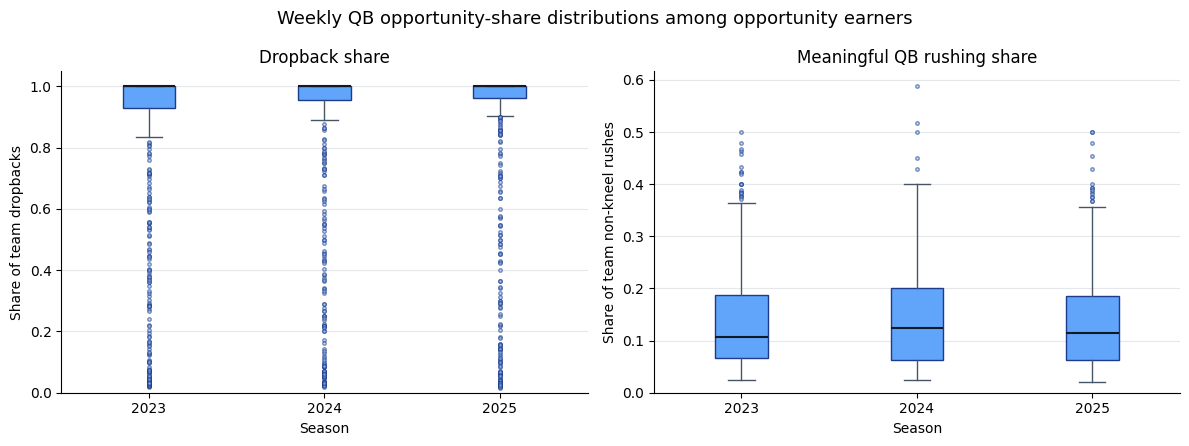

In [19]:
dropback_share_population = silver_qb_week.loc[silver_qb_week["qb_dropbacks"].gt(0)]
rush_share_population = silver_qb_week.loc[
    silver_qb_week["meaningful_qb_rush_attempts"].gt(0)
]
season_order = sorted(silver_qb_week["season"].unique())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

dropback_share_values = [
    dropback_share_population.loc[
        dropback_share_population["season"].eq(season), "dropback_share"
    ].dropna().astype("float64")
    for season in season_order
]
meaningful_rush_share_values = [
    rush_share_population.loc[
        rush_share_population["season"].eq(season), "meaningful_qb_rush_share"
    ].dropna().astype("float64")
    for season in season_order
]

box_style = {
    "patch_artist": True,
    "boxprops": {"facecolor": "#60a5fa", "edgecolor": "#1e3a8a"},
    "medianprops": {"color": "#111827", "linewidth": 1.5},
    "whiskerprops": {"color": "#475569"},
    "capprops": {"color": "#475569"},
    "flierprops": {
        "marker": "o",
        "markersize": 2.5,
        "markerfacecolor": "#93c5fd",
        "markeredgecolor": "#1e3a8a",
        "alpha": 0.55,
    },
}

axes[0].boxplot(dropback_share_values, tick_labels=season_order, **box_style)
axes[0].set_title("Dropback share")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Share of team dropbacks")

axes[1].boxplot(meaningful_rush_share_values, tick_labels=season_order, **box_style)
axes[1].set_title("Meaningful QB rushing share")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Share of team non-kneel rushes")

for axis in axes:
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", color="#e5e7eb", linewidth=0.8)
    axis.grid(axis="x", visible=False)
    axis.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "Weekly QB opportunity-share distributions among opportunity earners",
    fontsize=13,
)
fig.tight_layout()
plt.show()


Dropback share describes control of the team's passing role. Meaningful QB rushing share measures designed runs plus scrambles against all team non-kneel rushes; it intentionally excludes clock-management kneels.


### 17. Persist season-partitioned Silver Parquet

Each partition is written and immediately reloaded. Shape, columns, dtypes, season membership, and declared grain must survive the round trip.


In [20]:
QB_WEEK_DIR.mkdir(parents=True, exist_ok=True)

output_records = []
for season in SEASONS:
    qb_week_partition = (
        silver_qb_week.loc[silver_qb_week["season"].eq(season)]
        .sort_values(["week", "team", "player_id"])
        .reset_index(drop=True)
    )
    qb_week_path = QB_WEEK_DIR / f"qb_week_{season}.parquet"
    qb_week_partition.to_parquet(qb_week_path, index=False)
    qb_week_reloaded = pd.read_parquet(qb_week_path)

    assert qb_week_reloaded.shape == qb_week_partition.shape
    assert qb_week_reloaded.columns.tolist() == qb_week_partition.columns.tolist()
    assert (
        qb_week_reloaded.dtypes.astype(str).tolist()
        == qb_week_partition.dtypes.astype(str).tolist()
    )
    assert set(qb_week_reloaded["season"].unique()) == {season}
    assert not qb_week_reloaded.duplicated(QB_WEEK_GRAIN).any()

    output_records.append(
        {
            "dataset": "silver_qb_week",
            "season": season,
            "rows": len(qb_week_reloaded),
            "columns": len(qb_week_reloaded.columns),
            "grain": " + ".join(QB_WEEK_GRAIN),
            "duplicate_grain_rows": qb_week_reloaded.duplicated(QB_WEEK_GRAIN).sum(),
            "file_mb": qb_week_path.stat().st_size / 1024**2,
            "round_trip_passed": True,
        }
    )

output_summary = pd.DataFrame(output_records)

assert output_summary["rows"].sum() == len(silver_qb_week)
assert output_summary["duplicate_grain_rows"].eq(0).all()
assert output_summary["round_trip_passed"].all()

output_summary


,dataset,season,rows,columns,grain,duplicate_grain_rows,file_mb,round_trip_passed
0,silver_qb_week,2023,729,71,player_id + season + week + team,0,0.080519,True
1,silver_qb_week,2024,718,71,player_id + season + week + team,0,0.078779,True
2,silver_qb_week,2025,716,71,player_id + season + week + team,0,0.078264,True


In [21]:
print(
    f"Wrote {len(output_summary):,} QB-week files with "
    f"{output_summary['rows'].sum():,} total rows, "
    f"{len(silver_qb_week.columns):,} columns, and "
    f"{output_summary['file_mb'].sum():.2f} MB on disk."
)


Wrote 3 QB-week files with 2,163 total rows, 71 columns, and 0.24 MB on disk.


## Takeaways

- `silver_qb_week` contains 2,163 contextual QB player-weeks at `player_id + season + week + team`, with 729 rows in 2023, 718 in 2024, and 716 in 2025.
- All 63,783 canonical PBP dropbacks map to one player identifier. Scramble dropbacks use `rusher_player_id`; pass attempts and sacks use `passer_player_id`.
- Contextual QB rows contain 63,662 dropbacks, 56,108 pass attempts, 4,184 sacks, and 6,077 meaningful rush attempts.
- Meaningful rushing excludes 1,343 kneels and separates 2,707 designed runs from 3,370 scrambles. The resulting identities reconcile exactly on every row.
- Sacks and official rush attempts reconcile exactly with weekly stats. One documented source disagreement remains: Aaron Rodgers has one additional weekly-stat pass attempt in 2025 Week 2.
- The table preserves 54 snap-only QB rows. Their weekly-stat fields remain null, while complete PBP coverage establishes zero passing and rushing opportunity.
- No QB count exceeds its team denominator, and no same-week multi-team record violates the declared grain.
- Three 71-column season partitions pass schema, dtype, season, grain, and round-trip checks.
- Completing this notebook finishes the position-level Silver milestone and allows historical Draft Gold prototyping to begin.
